In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
iris = load_iris()
X = iris.data
y = (iris.target == 0).astype(int)  #0/1 setosa-no setosa

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [ ]:
#prediccion de probabilidades a partir de un rango
X_range = np.linspace(X_train[:,0].min(), X_train[:,0].max(), 300).reshape(-1,1)

In [ ]:
X_range = np.tile(X_range, (1,4))
y_prob = model.predict_proba(X_range)[:, 1]

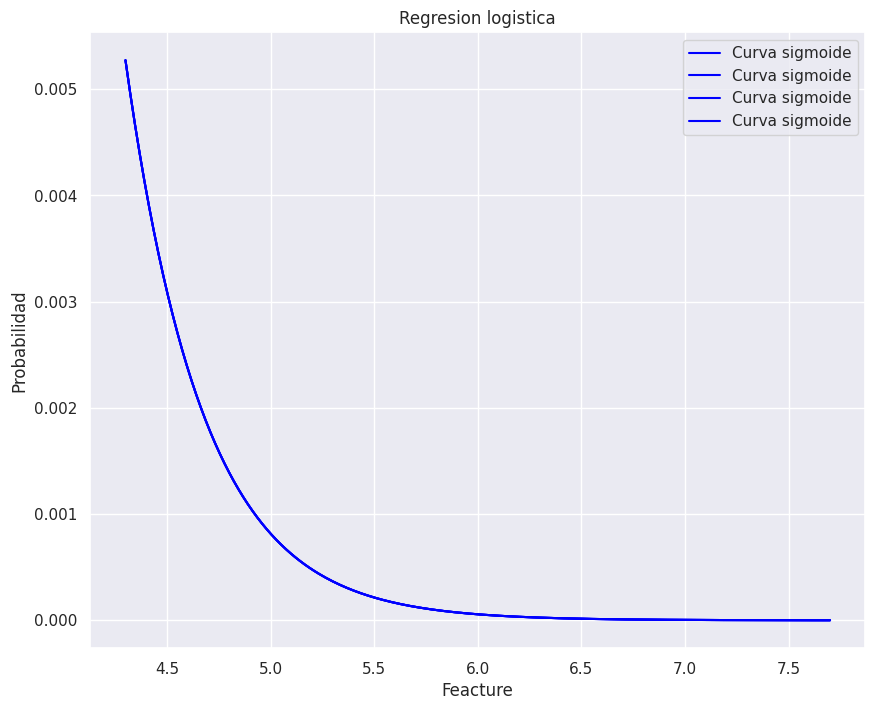

In [ ]:
sns.set(style='darkgrid')
plt.figure(figsize=(10,8))
plt.plot(X_range, y_prob, color='blue', label='Curva sigmoide')
plt.title('Regresion logistica')
plt.xlabel('Feacture')
plt.ylabel('Probabilidad')
plt.legend()
plt.show()

In [ ]:
import pandas as pd

data = {
    'edad': [22, 25, 47, 52, 46, 56, 28, 33, 41, 60],
    'salario': [2000, 2500, 5000, 6000, 5200, 6500, 3000, 4000, 4800, 7000],
    'compra': [0, 0, 1, 1, 1, 1, 0, 0, 1, 1]
}

df = pd.DataFrame(data)
df

,edad,salario,compra
0,22,2000,0
1,25,2500,0
2,47,5000,1
3,52,6000,1
4,46,5200,1
5,56,6500,1
6,28,3000,0
7,33,4000,0
8,41,4800,1
9,60,7000,1


In [ ]:
X = df[['edad', 'salario']]
y = df['compra']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_range = np.linspace(X_train['edad'].min(), X_train['edad'].max(), 300).reshape(-1,1)

In [ ]:
# Calculate mean of 'salario' from training data
mean_salario = X_train['salario'].mean()

# Create a prediction range with varying 'edad' and constant 'salario'
X_pred_range = np.column_stack((X_range, np.full(X_range.shape[0], mean_salario)))

# Get probabilities from the model trained on df
prob = model.predict_proba(X_pred_range)[:, 1]

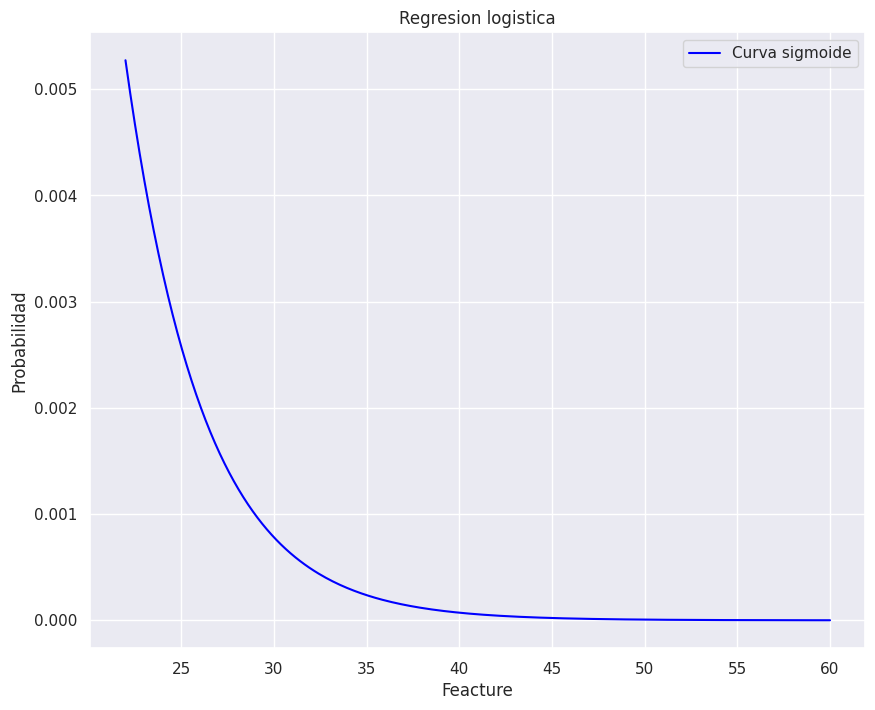

In [ ]:
sns.set(style='darkgrid')
plt.figure(figsize=(10,8))
plt.plot(X_range, prob, color='blue', label='Curva de Probabilidad') # Use 'prob' instead of 'y_prob'
plt.title('Probabilidad de Compra vs Edad (Salario Fijo)') # Updated title
plt.xlabel('Edad') # Updated xlabel
plt.ylabel('Probabilidad de Compra') # Updated ylabel
plt.legend()
plt.show()